# ***AG2 - Actividad Guiada 2***
Nombre: **Paula Caro Miralles**

Link:

Github:




In [37]:
import math
import numpy as np
import matplotlib.pyplot as plt

## **Programación Dinámica.**

* **Definición**: Es posible dividir el problema en subproblemas más pequeños, guardando las soluciones para ser utilizadas más adelante.
* **Características** que permiten identificar problemas aplicables:<br>
  - Es posible almacenar soluciones de los subproblemas para ser utilizados más adelante<br>
  - Debe verificar el principio de optimalidad de Bellman: “en una secuencia optima de decisiones, toda sub-secuencia también es óptima”<br>
  - La necesidad de guardar la información acerca de las soluciones parciales unido a la recursividad provoca la necesidad de preocuparnos por la complejidad espacial (cuantos recursos de espacio usaremos)<br>

### **Problema:** ***Viaje por el rio***
En un río hay **n** embarcaderos y debemos desplazarnos río abajo desde un embarcadero a otro. Cada embarcadero tiene precios diferentes para ir de un embarcadero a otro situado más abajo. Para ir del embarcadero $i$ al $j$, puede ocurrir que sea más barato hacer un trasbordo por un embarcadero intermedio $k$. El problema consiste en determinar la combinación más barata.

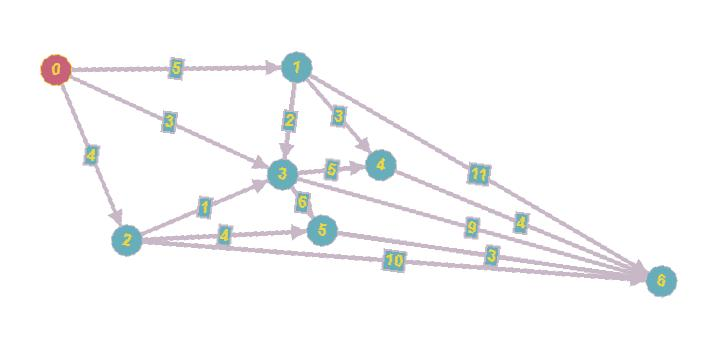

- Consideramos una tabla `TARIFAS(i,j)` para almacenar todos los precios que nos ofrecen los embarcaderos.<br>
- Si no es posible ir desde $i$ a $j$ daremos un valor alto para garantizar que ese trayecto no se va a elegir en la ruta óptima(modelado habitual para restricciones)

In [38]:
TARIFAS = [
[0,5,4,3,float("inf"),999,999],   #desde nodo 0
[999,0,999,2,3,999,11],  #desde nodo 1
[999,999, 0,1,999,4,10], #desde nodo 2
[999,999,999, 0,5,6,9],
[999,999, 999,999,0,999,4],
[999,999, 999,999,999,0,3],
[999,999,999,999,999,999,0]
]

#999 se puede sustituir por float("inf") del modulo math
TARIFAS

[[0, 5, 4, 3, inf, 999, 999],
 [999, 0, 999, 2, 3, 999, 11],
 [999, 999, 0, 1, 999, 4, 10],
 [999, 999, 999, 0, 5, 6, 9],
 [999, 999, 999, 999, 0, 999, 4],
 [999, 999, 999, 999, 999, 0, 3],
 [999, 999, 999, 999, 999, 999, 0]]

In [39]:
#Calculo de la matriz de PRECIOS y RUTAS
#  PRECIOS - contiene la matriz del mejor precio para ir de un nodo a otro
#  RUTAS   - contiene los nodos intermedios para ir de un nodo a otro
################################################################
def Precios(TARIFAS):
################################################################
  #Total de Nodos
  N = len(TARIFAS[0])

  #Inicialización de la tabla de precios
  PRECIOS = [ [float("inf")]*N for i in [float("inf")]*N]  #n x n
  RUTA = [ [""]*N for i in [""]*N]

  #Se recorren todos los nodos con dos bucles(origen - destino)
  #  para ir construyendo la matriz de PRECIOS
  for i in range(N-1):
    for j in range(i+1, N):
      MIN = TARIFAS[i][j]
      RUTA[i][j] = i

      for k in range(i, j):
        if PRECIOS[i][k] + TARIFAS[k][j] < MIN:
            MIN = min(MIN, PRECIOS[i][k] + TARIFAS[k][j] )
            RUTA[i][j] = k
        PRECIOS[i][j] = MIN

  return PRECIOS,RUTA

In [40]:
PRECIOS,RUTA = Precios(TARIFAS)
#print(PRECIOS[0][6])

print("PRECIOS")
for i in range(len(TARIFAS)):
  print(PRECIOS[i])

print("\nRUTA")
for i in range(len(TARIFAS)):
  print(RUTA[i])

PRECIOS
[inf, 5, 4, 3, 8, 8, 11]
[inf, inf, 999, 2, 3, 8, 7]
[inf, inf, inf, 1, 6, 4, 7]
[inf, inf, inf, inf, 5, 6, 9]
[inf, inf, inf, inf, inf, 999, 4]
[inf, inf, inf, inf, inf, inf, 3]
[inf, inf, inf, inf, inf, inf, inf]

RUTA
['', 0, 0, 0, 1, 2, 5]
['', '', 1, 1, 1, 3, 4]
['', '', '', 2, 3, 2, 5]
['', '', '', '', 3, 3, 3]
['', '', '', '', '', 4, 4]
['', '', '', '', '', '', 5]
['', '', '', '', '', '', '']


In [41]:
#Calculo de la ruta usando la matriz RUTA
def calcular_ruta(RUTA, desde, hasta):
  if desde == RUTA[desde][hasta]:
  #if desde == hasta:
    #print("Ir a :" + str(desde))
    return desde
  else:
    return str(calcular_ruta(RUTA, desde, RUTA[desde][hasta])) +  ',' + str(RUTA[desde][hasta])

print("\nLa ruta es:")
calcular_ruta(RUTA, 0,6)


La ruta es:


'0,2,5'

## **Ramificación y Poda:** Problema de Asignacion de tarea

- El problema consiste en maximizar el rendimiento (o minimizar los costes) en
cuanto a la asignación de N tareas a N agentes. Cada tarea solo puede ser
asignado a un agente.
- Los beneficios que se obtienen al realizar la tarea 1 por el agente A es 11
- La matriz de beneficios es la que se muestra en la figura
- Aplicando Ramificación y Poda, obtener la asignación que maximice los
beneficios.

In [42]:
#Asignacion de tareas - Ramificación y Poda
################################################################################
#      T A R E A
#   A
#   G
#   E
#   N
#   T
#   E

COSTES = [[11, 12, 18, 40],
          [14, 15, 13, 22],
          [11, 17, 19, 23],
          [17, 14, 20, 28]]


In [43]:
# Calculo del valor de una solucion parcial
def valor(S,COSTES):
    VALOR = 0
    for i in range(len(S)):
        VALOR += COSTES[S[i]][i]
       # i = 0
       #  Valor = 0 + 17 (COSTES[3, 0])
       # i = 1 
       #  Valor = 17 + 17 (COSTES[2, 1])
    return VALOR



valor((3,2,  ), COSTES)

34

In [44]:
#Coste inferior para soluciones parciales
#  (1,3,) Se asigna la tarea 1 al agente 0 y la tarea 3 al agente 1

def CI(S,COSTES):
  VALOR = 0
  #Valores establecidos
  for i in range(len(S)):
    VALOR += COSTES[i][S[i]]

  #Estimacion
  for i in range( len(S), len(COSTES)   ):
    VALOR += min( [ COSTES[j][i] for j in range(len(S), len(COSTES))  ])
  return VALOR

def CS(S,COSTES):
  VALOR = 0
  #Valores establecidos
  for i in range(len(S)):
    VALOR += COSTES[i][S[i]]

  #Estimacion
  for i in range( len(S), len(COSTES)   ):
    VALOR += max( [ COSTES[j][i] for j in range(len(S), len(COSTES))  ])
  return VALOR

CI((1,3),COSTES)

76

In [45]:
#Genera tantos hijos como como posibilidades haya para la siguiente elemento de la tupla
#(0,) -> (0,1), (0,2), (0,3)
def crear_hijos(NODO, N):
  HIJOS = []
  for i in range(N ):
    if i not in NODO:
      HIJOS.append({'s':NODO +(i,)    })
  return HIJOS

In [46]:
crear_hijos((0,) , 4)

[{'s': (0, 1)}, {'s': (0, 2)}, {'s': (0, 3)}]

In [47]:
def ramificacion_y_poda(COSTES):
#Construccion iterativa de soluciones(arbol). En cada etapa asignamos un agente(ramas).
#Nodos del grafo  { s:(1,2),CI:3,CS:5  }
  #print(COSTES)
  DIMENSION = len(COSTES)
  MEJOR_SOLUCION  = tuple( i for i in range(len(COSTES)) )
  CotaSup = valor(MEJOR_SOLUCION,COSTES)
  #print("Cota Superior:", CotaSup)

  NODOS=[]  # Almacenamos nodos/ramas que nos interesen
  NODOS.append({'s':(), 'ci':CI((),COSTES)    } )

  iteracion = 0

  while( len(NODOS) > 0):
    iteracion +=1

    nodo_prometedor = [ min(NODOS, key=lambda x:x['ci']) ][0]['s']
    #print("Nodo prometedor:", nodo_prometedor)

    #Ramificacion
    #Se generan los hijos
    HIJOS =[ {'s':x['s'], 'ci':CI(x['s'], COSTES)   } for x in crear_hijos(nodo_prometedor, DIMENSION) ]

    #Revisamos la cota superior y nos quedamos con la mejor solucion si llegamos a una solucion final
    NODO_FINAL = [x for x in HIJOS if len(x['s']) == DIMENSION  ]
    if len(NODO_FINAL ) >0:
      #print("\n********Soluciones:",  [x for x in HIJOS if len(x['s']) == DIMENSION  ] )
      if NODO_FINAL[0]['ci'] < CotaSup:
        CotaSup = NODO_FINAL[0]['ci']
        MEJOR_SOLUCION = NODO_FINAL

    #Poda
    HIJOS = [x for x in HIJOS if x['ci'] < CotaSup   ]

    #Añadimos los hijos
    NODOS.extend(HIJOS)

    #Eliminamos el nodo ramificado
    NODOS =  [  x for x in NODOS if x['s'] != nodo_prometedor    ]

  print("La solucion final es:" ,MEJOR_SOLUCION , " en " , iteracion , " iteraciones" , " para dimension: " ,DIMENSION  )



ramificacion_y_poda(COSTES)

La solucion final es: [{'s': (1, 2, 0, 3), 'ci': 64}]  en  10  iteraciones  para dimension:  4


## **Descenso del gradiente**

In [48]:
import math                      #Funciones matematicas
import matplotlib.pyplot as plt  #Generacion de gráficos (otra opcion seaborn)
import numpy as np               #Tratamiento matriz N-dimensionales y otras (fundamental!)
#import scipy as sc

import random

Vamos a buscar el minimo de la funcion paraboloide : $$f(x) =  x² + y²$$

Obviamente se encuentra en (x,y)=(0,0) pero probaremos como llegamos a él a través del descenso del gradiante.

In [49]:
#Definimos la funcion
#Paraboloide
f  = lambda X:      X[0]**2 + X[1]**2    #Funcion
df = lambda X: [2*X[0] , 2*X[1]]         #Gradiente

df([1,2])

[2, 4]

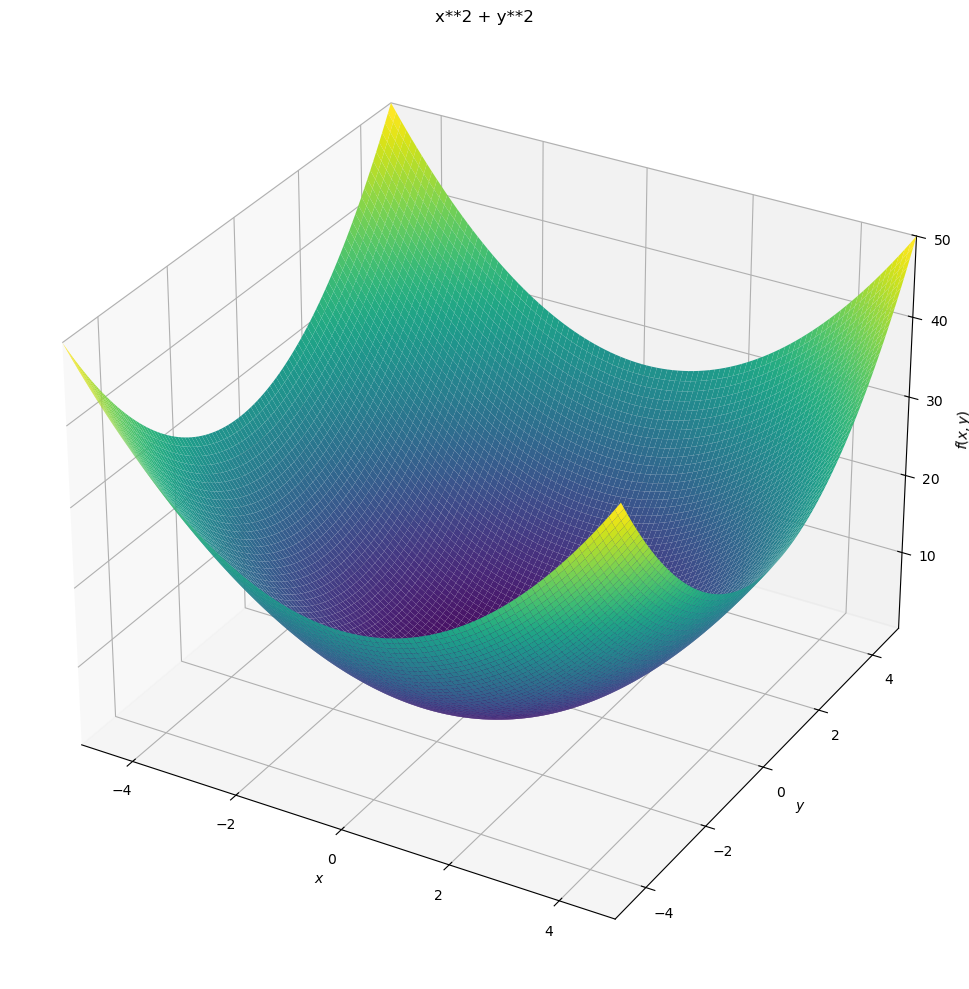

In [50]:
from sympy import symbols
from sympy.plotting import plot
from sympy.plotting import plot3d

x,y = symbols('x y')
plot3d(x**2 + y**2,
       (x,-5,5),(y,-5,5),
       title='x**2 + y**2',
       size=(10,10))

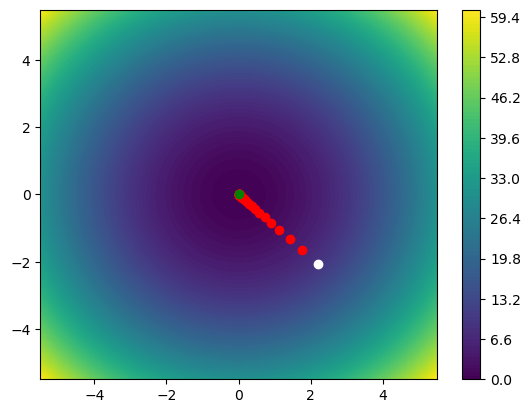

Solucion: [3.1508224430705097e-05, -2.9353833358601356e-05] 1.8544157396202194e-09


In [51]:
#Preparamos los datos para dibujar mapa de niveles de Z
resolucion = 100
rango=5.5

X=np.linspace(-rango,rango,resolucion)
Y=np.linspace(-rango,rango,resolucion)
Z=np.zeros((resolucion,resolucion))
for ix,x in enumerate(X):
  for iy,y in enumerate(Y):
    Z[iy,ix] = f([x,y])

#Pinta el mapa de niveles de Z
plt.contourf(X,Y,Z,resolucion)
plt.colorbar()

#Generamos un punto aleatorio inicial y pintamos de blanco
P=[random.uniform(-5,5),random.uniform(-5,5)]
plt.plot(P[0],P[1],"o",c="white")

#Tasa de aprendizaje. Fija. Sería más efectivo reducirlo a medida que nos acercamos.
TA=.1

#Iteraciones:50
for it in range(50):
  # print(f"Iteración Número: {it}.")
  grad = df(P)
  # print(P,grad)
  P[0],P[1] = P[0] - TA*grad[0] , P[1] - TA*grad[1]
  plt.plot(P[0],P[1],"o",c="red")

#Dibujamos el punto final y pintamos de verde
plt.plot(P[0],P[1],"o",c="green")
plt.show()
print("Solucion:" , P , f(P))


## **EJERCICIO EXTRA:**

Optimizar la función:
$$\begin{align*}
f(x, y) &= sin(x^2/2 - y^2/4 + 3) \cdot cos(2x + 1 - e^y) \\
\end{align*}$$
Con derivadas parciales:
$$\begin{align*}
\frac{df}{dx} (x, y) &= [x \cdot cos(x^2/2 - y^2/4 + 3) \cdot cos(2x + 1 - e^y)] - [2\cdot sin(x^2/2 - y^2/4 + 3) \cdot sin(2x + 1 - e^y)] \\
\frac{df}{dy} (x, y) &= [-y/2 \cdot cos(x^2/2 - y^2/4 + 3) \cdot cos(2x + 1 - e^y)] + [e^y\cdot sin(x^2/2 - y^2/4 + 3) \cdot sin(2x + 1 - e^y)]
\end{align*}$$

Vamos a seguir el mismo procedimiento que para la anterior función. En este caso, observamos que $f(x, y) \in [-1, 1], \forall (x, y)$, ya que tanto el seno como el coseno tienen la imágen en este intervalo.

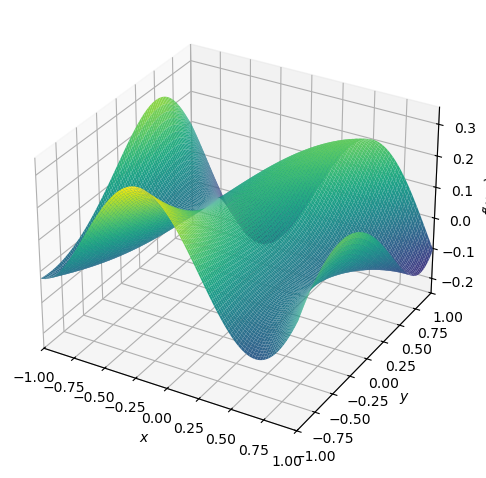

In [52]:
import sympy as sp
from sympy.plotting import plot3d

# Definimos las variables simbólicas
x, y = sp.symbols('x y')

# Definimos la función simbólica
f_sym = sp.sin(x**2/2 - y**2/4 + 3) * sp.cos(2*x + 1 - sp.exp(y))

# Derivamos
df_dx = sp.diff(f_sym, x) # Derivada respecto a x
df_dy = sp.diff(f_sym, y) # Derivada respecto a y

# print("--- Derivada respecto a X ---")
# sp.pprint(df_dx)
# print("\n--- Derivada respecto a Y ---")
# sp.pprint(df_dy)

# Convertimos esta fórmula simbólica a una función Numpy
f_num = sp.lambdify((x, y), f_sym, 'numpy')
df_num_x = sp.lambdify((x, y), df_dx, 'numpy')
df_num_y = sp.lambdify((x, y), df_dy, 'numpy')
df = [df_num_x, df_num_y]

# Ploteamos la función
plot3d(f_sym, 
       (x, -1, 1), 
       (y, -1, 1))

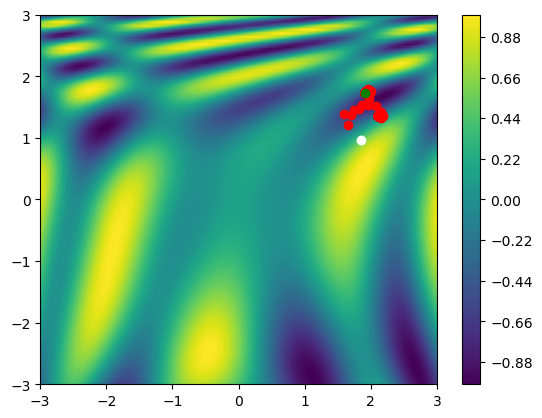

Solucion: [1.9105815801944697, 1.7363480115372143] -0.525726972282233


In [58]:
import numpy as np

# Preparamos los datos para dibujar mapa de niveles de Z
resolucion = 100
rango=3

X = np.linspace(-rango,rango,resolucion)
Y = np.linspace(-rango,rango,resolucion)
Z = np.zeros((resolucion,resolucion))

for ix,x in enumerate(X):
  for iy,y in enumerate(Y):
    Z[iy,ix] = f_num(x,y)

# Pintamos el mapa de niveles de Z
plt.contourf(X,Y,Z,resolucion)
plt.colorbar()

# Generamos un punto aleatorio inicial y lo pintamos de blanco
r = 2
P=[random.uniform(-r, r),random.uniform(-r, r)]
plt.plot(P[0],P[1],"o",c="white")

#Tasa de aprendizaje Inicial.
TA = 0.1

# Iteraciones:500
for it in range(500):
  grad = [df_num_x(P[0], P[1]), df_num_y(P[0], P[1])]

  # print(P, grad)
  P[0],P[1] = P[0] - TA*grad[0] , P[1] - TA*grad[1]
  plt.plot(P[0],P[1],"o",c="red")

#Dibujamos el punto final y pintamos de verde
plt.plot(P[0],P[1],"o",c="green")
plt.show()
print("Solucion:" , P , f_num(*P))


Observamos que esta técnica es bastante inestable:

1. Por una parte, a causa de $e^y$, tenemos una **explosión del gradiente**. Esto implica que si el punto aleatorio cae en un número grande, con una tasa de 0.1, el salto será gigante y el punto se irá al infinito u oscilará caóticamente. Para resolver este problema, aplicaremos "**Gradient Clipping**", esto es, reducir el rango de búsqueda inicial. Lo haremos normalizando el gradiente en cada caso.
2. Por otra parte, como la función $f$ es una composición de senos y cosenos, tiene muchos mínimos locales. Para solucionar este problema, aplicaremos el **Multi-Start**. Esto es, en lugar de iniciar con un único punto aleatorio, realizaremos el proceso con 50 puntos aleatorios y al final nos quedaremos con el mejor mínimo local y lo consideraremos como mínimo global. 

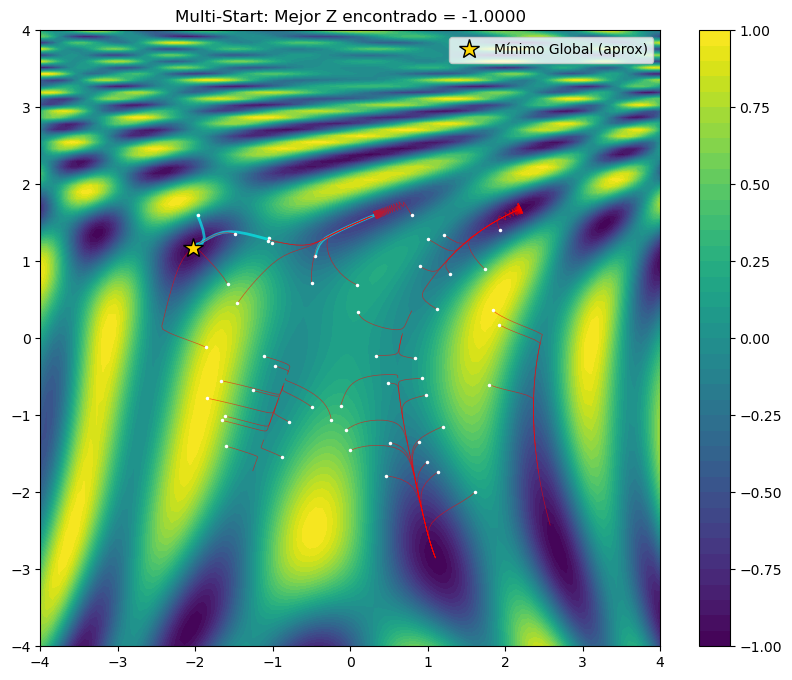

El mejor punto encontrado tras 50 intentos es: [-2.027650617820537, 1.171826836361827]
Y el valor de la función en este punto es: -1.0


In [68]:
resolucion = 100
rango = 4

X = np.linspace(-rango, rango, resolucion)
Y = np.linspace(-rango, rango, resolucion)
Z = np.zeros((resolucion, resolucion))
for ix, x in enumerate(X):
    for iy, y in enumerate(Y):
        Z[iy, ix] = f_num(x, y)

plt.figure(figsize=(10, 8))
plt.contourf(X, Y, Z, levels=40, cmap='viridis')
plt.colorbar()

# --- ALGORITMO MULTI-START ---
num_intentos = 50      
mejor_global_z = float('inf')
mejor_global_p = None

for intento in range(num_intentos):
    # Generamos punto aleatorio
    r = 2
    P = [random.uniform(-r, r),random.uniform(-r, r)]
    
    # Parámetros del descenso
    TA = .1
    path_x, path_y = [P[0]], [P[1]] # Para guardar el camino
    
    for it in range(50):
        grad_x = df_num_x(P[0], P[1])
        grad_y = df_num_y(P[0], P[1])
        
        # Clipping para evitar explosiones
        norma = np.sqrt(grad_x**2 + grad_y**2)
        if norma > 1.0:
            grad_x, grad_y = grad_x/norma, grad_y/norma
            
        P[0] = P[0] - TA * grad_x
        P[1] = P[1] - TA * grad_y
        
        path_x.append(P[0])
        path_y.append(P[1])
    
    z_final = f_num(*P)
    
    if z_final < mejor_global_z:
        mejor_global_z = z_final
        mejor_global_p = list(P)
        color_camino = "cyan" 
        grosor = 2
    else:
        color_camino = "red"
        grosor = 0.5
        
    plt.plot(path_x, path_y, "-", c=color_camino, alpha=0.6, linewidth=grosor)
    plt.plot(path_x[0], path_y[0], ".", c="white", markersize=3) 


# --- RESULTADO FINAL ---
plt.plot(mejor_global_p[0], mejor_global_p[1], "*", c="gold", markersize=15, markeredgecolor="black", label="Mínimo Global (aprox)")
plt.legend()
plt.title(f"Multi-Start: Mejor Z encontrado = {mejor_global_z:.4f}")
plt.show()

print(f"El mejor punto encontrado tras {num_intentos} intentos es: {mejor_global_p}")
print(f"Y el valor de la función en este punto es: {f_num(*mejor_global_p)}")

Hemos encontrado que en el punto $(-2..027, 1.172)$, el valor de la función es de $-1$. Que, recordando lo comentado al principio, es el mejor mínimo que podríamos encontrar.